<a href="https://colab.research.google.com/github/Vishal-Mungal/NNDLPRACTICAL/blob/main/NNDL_Pr8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Autoencoders for Dimensionality Reduction and Feature Learning

This notebook demonstrates how to implement a Deep Autoencoder using TensorFlow and Keras. We will train the autoencoder on the MNIST dataset to learn a low-dimensional representation (bottleneck/latent space) and then reconstruct the original inputs from this representation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

# Set random seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

## 1. Load and Preprocess the Dataset
We will use the MNIST dataset of handwritten digits. We normalize the pixel values to the range [0, 1] and flatten the 28x28 images into a 784-dimensional vector to feed into our dense autoencoder layers.

In [2]:
# Load MNIST dataset
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

# Normalize pixel values
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Flatten the 28x28 images to vectors of size 784
x_train_flat = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test_flat = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

print(f"Training data shape: {x_train_flat.shape}")
print(f"Test data shape: {x_test_flat.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 784)
Test data shape: (10000, 784)


## 2. Build the Autoencoder Architecture
We will reduce the 784-dimensional input down to a **32-dimensional** latent representation (compression factor of 24.5), and then reconstruct it back to 784 dimensions.

In [3]:
input_dim = 784
encoding_dim = 32  # Size of the bottleneck layer

# Define Input
input_img = layers.Input(shape=(input_dim,))

# Encoder Layers
encoded = layers.Dense(128, activation='relu')(input_img)
encoded = layers.Dense(64, activation='relu')(encoded)
latent_space = layers.Dense(encoding_dim, activation='relu', name='bottleneck')(encoded)

# Decoder Layers
decoded = layers.Dense(64, activation='relu')(latent_space)
decoded = layers.Dense(128, activation='relu')(decoded)
decoded = layers.Dense(input_dim, activation='sigmoid')(decoded)

# Models definitions
# 1. Full Autoencoder (Input -> Reconstruction)
autoencoder = models.Model(input_img, decoded)

# 2. Separate Encoder Model (Input -> Latent Space) for Dimensionality Reduction
encoder = models.Model(input_img, latent_space)

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Train the Autoencoder
We train the model using `x_train_flat` as both the input and the target output.

In [8]:
history = autoencoder.fit(
    x_train_flat, x_train_flat,
    epochs=5,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_flat, x_test_flat)
)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0889 - val_loss: 0.0882
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0886 - val_loss: 0.0879
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0882 - val_loss: 0.0877
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0879 - val_loss: 0.0874
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.0876 - val_loss: 0.0872


## 4. Visualize Reconstruction & Learn Features
Now we extract both the reduced features (32-dimensional bottleneck) and reconstruct the original test images back to 784-dimensional space.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


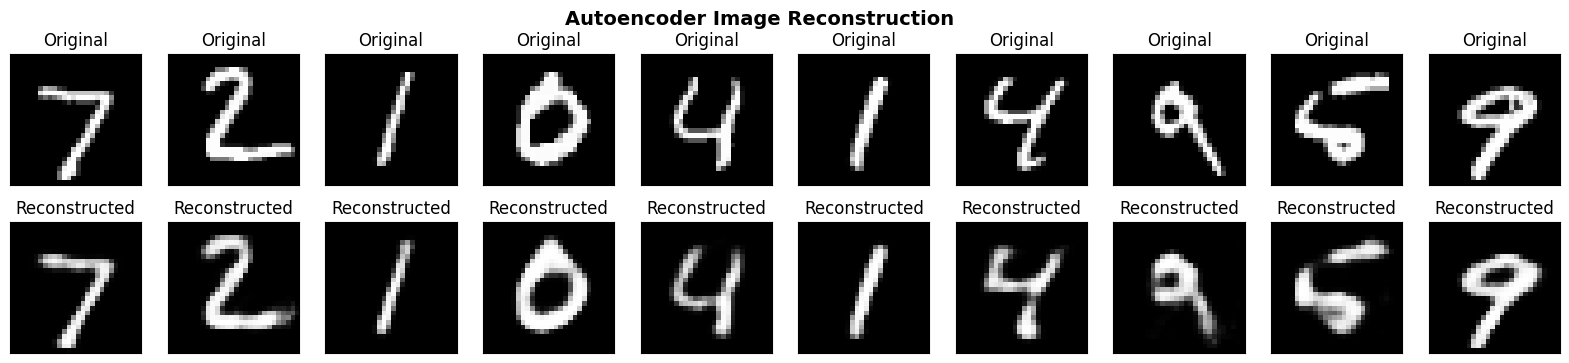

Original vector size: 784
Reduced latent feature size: 32


In [9]:
# Compress the test images using the encoder
encoded_imgs = encoder.predict(x_test_flat)

# Reconstruct the test images using the full autoencoder
reconstructed_imgs = autoencoder.predict(x_test_flat)

# Display Original vs Reconstructed
n = 10  # Number of digits to display
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display Reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstructed")
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.suptitle("Autoencoder Image Reconstruction", fontsize=14, fontweight='bold')
plt.show()

# Print representation shape to confirm dimensionality reduction
print(f"Original vector size: {x_test_flat.shape[1]}")
print(f"Reduced latent feature size: {encoded_imgs.shape[1]}")